
# [PHASE3] CyberCast Learned World Model

**Project:** CyberCast
**Phase:** Phase 3 — Learned Network World Model (Phase 3.1 & 3.2 V3)
**SIH Problem:** Problem Statement 26153

**Objective:**
Learn temporal network-state transition dynamics $P(S_{t+1} | S_{t-H+1}, ..., S_t)$ to predict the NEXT OBSERVABLE STATE.


In [1]:

import pandas as pd
import numpy as np
import os
import gc
from pathlib import Path
import json
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import pearsonr, spearmanr
import warnings
warnings.filterwarnings('ignore')

# Environment + Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

print("--- ENVIRONMENT ---")
print(f"Pandas version: {pd.__version__}")
print(f"Numpy version: {np.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print("Random seeds set.")

DATA_DIR = Path("../../data/raw")
RESULTS_DIR = Path("../../results/phase3")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
(RESULTS_DIR / "state").mkdir(exist_ok=True)
(RESULTS_DIR / "audit").mkdir(exist_ok=True)
(RESULTS_DIR / "world_model").mkdir(exist_ok=True)
(Path("../../models/production")).mkdir(parents=True, exist_ok=True)


--- ENVIRONMENT ---
Pandas version: 2.2.3
Numpy version: 1.26.4
PyTorch version: 2.5.1+cu121
CUDA available: True
Device: cuda
Random seeds set.



## [PHASE 3.1] DATA AUDIT & CACHE FAST-PATH


In [2]:

S_t_path = RESULTS_DIR / "state" / "S_t.parquet"
Y_t_path = RESULTS_DIR / "state" / "Y_t.parquet"
schema_path = RESULTS_DIR / "state" / "state_schema.json"

USE_CACHE = False
if S_t_path.exists() and Y_t_path.exists() and schema_path.exists():
    print("PHASE 3.1 DATA SOURCE: FROZEN PARQUET ARTIFACT")
    S_t = pd.read_parquet(S_t_path)
    Y_t = pd.read_parquet(Y_t_path)
    with open(schema_path, "r") as f:
        schema = json.load(f)
        
    assert len(S_t.columns) == 77, "Expected exactly 77 S_t features"
    USE_CACHE = True
    print("Phase 3.1 Cache verified. Proceeding to Phase 3.2.")
else:
    raise FileNotFoundError("Missing frozen artifacts.")


PHASE 3.1 DATA SOURCE: FROZEN PARQUET ARTIFACT
Phase 3.1 Cache verified. Proceeding to Phase 3.2.



## [PHASE 3.2 V3] WORLD MODEL BASELINE (PRIMITIVE DEPENDENCY MAPPING)

### Scope & Constraints
- Learn $P(R_{t+1} | S_{t-H+1}, ..., S_t)$ where $H=20$.
- Input: exactly 77 features.
- Output: 65 Primitive Features.
- Softplus Output Activation for physical non-negativity.
- Target Representation: $log1p(x) / RMS(log1p(x_{train}))$
- Deterministic Reconstruction for derived features.


In [3]:

# Hyperparameters
H = 20
HIDDEN_SIZE = 128
LAYERS = 2
DROPOUT = 0.2
BATCH_SIZE = 256
MAX_EPOCHS = 50
PATIENCE = 7
LEARNING_RATE = 1e-3
EPSILON = 1e-6

feature_names = list(S_t.columns)

# Load Dependency Map
with open(RESULTS_DIR / "world_model" / "state_dependency_map.json", "r") as f:
    dep_map = json.load(f)

derived_features = [f for f, d in dep_map.items() if not d["predicted_directly"]]
primitive_features = [f for f, d in dep_map.items() if d["predicted_directly"]]
print(f"Primitive Features: {len(primitive_features)}")
print(f"Derived Features: {len(derived_features)}")
assert len(primitive_features) + len(derived_features) == 77

primitive_indices = [feature_names.index(f) for f in primitive_features]
derived_indices = [feature_names.index(f) for f in derived_features]

N_states = len(S_t)
idx_80 = int(0.8 * N_states)
idx_90 = int(0.9 * N_states)

train_states = S_t.iloc[:idx_80].copy()
val_states = S_t.iloc[idx_80:idx_90].copy()
test_states = S_t.iloc[idx_90:].copy()

# Input Scaling (log1p -> StandardScaler)
# Note: Input scaler is fitted on ALL 77 features
train_orig = train_states.values
val_orig = val_states.values
test_orig = test_states.values

train_transformed_in = np.log1p(np.maximum(train_orig, 0))
val_transformed_in = np.log1p(np.maximum(val_orig, 0))
test_transformed_in = np.log1p(np.maximum(test_orig, 0))

input_scaler = StandardScaler()
train_scaled_in = input_scaler.fit_transform(train_transformed_in)
val_scaled_in = input_scaler.transform(val_transformed_in)
test_scaled_in = input_scaler.transform(test_transformed_in)

import joblib
joblib.dump(input_scaler, "../../models/production/world_model_scaler_v3.joblib")
print("Input Scaler saved.")

# Target Representation (Primitive Only)
# model_target_j = log_target_j / scale_j
# scale_j = max(RMS(log_target_train[:,j]), epsilon)

train_orig_prim = train_orig[:, primitive_indices]
val_orig_prim = val_orig[:, primitive_indices]
test_orig_prim = test_orig[:, primitive_indices]

train_log_prim = np.log1p(np.maximum(train_orig_prim, 0))
val_log_prim = np.log1p(np.maximum(val_orig_prim, 0))
test_log_prim = np.log1p(np.maximum(test_orig_prim, 0))

# RMS Scaling
rms_train = np.sqrt(np.mean(train_log_prim**2, axis=0))
target_scales = np.maximum(rms_train, EPSILON)

np.save("../../models/production/world_model_target_scales_v3.npy", target_scales)

train_target_scaled = train_log_prim / target_scales
val_target_scaled = val_log_prim / target_scales
test_target_scaled = test_log_prim / target_scales


Primitive Features: 65
Derived Features: 12
Input Scaler saved.



### Sequence Construction


In [4]:

class PrimitiveTransitionDataset(Dataset):
    def __init__(self, X_scaled, Y_target, X_orig, history_len):
        self.X_scaled = X_scaled
        self.Y_target = Y_target
        self.X_orig = X_orig
        self.history_len = history_len
        self.N = len(X_scaled)
        
    def __len__(self):
        return self.N - self.history_len
        
    def __getitem__(self, idx):
        # Input: 77 features
        X = self.X_scaled[idx : idx + self.history_len]
        # Target: Primitive features only
        Y = self.Y_target[idx + self.history_len]
        
        # Original (unscaled) full 77 states for persistence baseline & derived metric eval
        Y_orig = self.X_orig[idx + self.history_len]
        X_last_orig = self.X_orig[idx + self.history_len - 1]
        
        return torch.tensor(X, dtype=torch.float32),                torch.tensor(Y, dtype=torch.float32),                torch.tensor(X_last_orig, dtype=torch.float32),                torch.tensor(Y_orig, dtype=torch.float32)

train_ds = PrimitiveTransitionDataset(train_scaled_in, train_target_scaled, train_orig, H)
val_ds = PrimitiveTransitionDataset(val_scaled_in, val_target_scaled, val_orig, H)
test_ds = PrimitiveTransitionDataset(test_scaled_in, test_target_scaled, test_orig, H)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

sample_X, sample_Y, _, _ = train_ds[0]
assert sample_X.shape == (H, 77)
assert sample_Y.shape == (len(primitive_features),)



### LSTM World Model Architecture with Softplus


In [5]:

class CyberCastWorldModelV3(nn.Module):
    def __init__(self, input_dim=77, output_dim=65, hidden_dim=128, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_dim, 
                            hidden_size=hidden_dim, 
                            num_layers=num_layers, 
                            batch_first=True, 
                            dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.softplus = nn.Softplus()
        
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_out = lstm_out[:, -1, :]
        logits = self.fc(last_out)
        return self.softplus(logits) # Strictly positive outputs

model = CyberCastWorldModelV3(input_dim=77, output_dim=len(primitive_features), 
                              hidden_dim=HIDDEN_SIZE, num_layers=LAYERS, dropout=DROPOUT).to(device)
criterion = nn.HuberLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
print(model)


CyberCastWorldModelV3(
  (lstm): LSTM(77, 128, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=128, out_features=65, bias=True)
  (softplus): Softplus(beta=1.0, threshold=20.0)
)



### Training


In [6]:

best_val_loss = float('inf')
patience_counter = 0
best_model_path = "../../models/production/world_model_baseline_v3.pt"

for epoch in range(MAX_EPOCHS):
    model.train()
    train_loss = 0.0
    for X_batch, Y_batch, _, _ in train_loader:
        X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, Y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * X_batch.size(0)
    train_loss /= len(train_loader.dataset)
    
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, Y_batch, _, _ in val_loader:
            X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
            preds = model(X_batch)
            loss = criterion(preds, Y_batch)
            val_loss += loss.item() * X_batch.size(0)
    val_loss /= len(val_loader.dataset)
    
    print(f"Epoch {epoch+1:02d}/{MAX_EPOCHS} | Train Huber: {train_loss:.4f} | Val Huber: {val_loss:.4f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
    else:
        patience_counter += 1
        
    if patience_counter >= PATIENCE:
        print(f"Early stopping triggered after {epoch+1} epochs.")
        break

model.load_state_dict(torch.load(best_model_path))


Epoch 01/50 | Train Huber: 0.0466 | Val Huber: 0.0271


Epoch 02/50 | Train Huber: 0.0281 | Val Huber: 0.0260


Epoch 03/50 | Train Huber: 0.0264 | Val Huber: 0.0255


Epoch 04/50 | Train Huber: 0.0253 | Val Huber: 0.0252


Epoch 05/50 | Train Huber: 0.0247 | Val Huber: 0.0250


...

Epoch 26/50 | Train Huber: 0.0215 | Val Huber: 0.0239


Epoch 27/50 | Train Huber: 0.0214 | Val Huber: 0.0240


Epoch 28/50 | Train Huber: 0.0213 | Val Huber: 0.0239


Epoch 29/50 | Train Huber: 0.0211 | Val Huber: 0.0238
Early stopping triggered after 29 epochs.


<All keys matched successfully>


### Deterministic Reconstruction & Blind Evaluation


In [7]:

def reconstruct_state(prim_preds_orig, feature_names):
    # prim_preds_orig shape: (N, 65)
    # We must construct (N, 77)
    N = len(prim_preds_orig)
    S_hat = np.zeros((N, 77), dtype=np.float32)
    
    # 1. Fill Primitives
    for i, feat in enumerate(primitive_features):
        idx = feature_names.index(feat)
        S_hat[:, idx] = prim_preds_orig[:, i]
        
    # Helpers
    def get_col(f): return S_hat[:, feature_names.index(f)]
    def set_col(f, val): S_hat[:, feature_names.index(f)] = val
    
    # 2. Derive Deterministic
    # Rates
    set_col('Flow Pkts/s', (get_col('Tot Fwd Pkts') + get_col('Tot Bwd Pkts')) / 10.0)
    set_col('Fwd Pkts/s', get_col('Tot Fwd Pkts') / 10.0)
    set_col('Bwd Pkts/s', get_col('Tot Bwd Pkts') / 10.0)
    set_col('Flow Byts/s', (get_col('TotLen Fwd Pkts') + get_col('TotLen Bwd Pkts')) / 10.0)
    
    # Means
    fwd_pkts = get_col('Tot Fwd Pkts')
    bwd_pkts = get_col('Tot Bwd Pkts')
    tot_pkts = fwd_pkts + bwd_pkts
    
    set_col('Fwd Pkt Len Mean', np.where(fwd_pkts > 0, get_col('TotLen Fwd Pkts') / fwd_pkts, 0.0))
    set_col('Bwd Pkt Len Mean', np.where(bwd_pkts > 0, get_col('TotLen Bwd Pkts') / bwd_pkts, 0.0))
    set_col('Pkt Len Mean', np.where(tot_pkts > 0, (get_col('TotLen Fwd Pkts') + get_col('TotLen Bwd Pkts')) / tot_pkts, 0.0))
    
    # Ratios
    set_col('Down/Up Ratio', np.where(fwd_pkts > 0, bwd_pkts / fwd_pkts, 0.0))
    
    # Synonyms
    set_col('Pkt Size Avg', get_col('Pkt Len Mean'))
    set_col('Subflow Fwd Pkts', get_col('Tot Fwd Pkts'))
    set_col('Subflow Fwd Byts', get_col('TotLen Fwd Pkts'))
    set_col('Subflow Bwd Pkts', get_col('Tot Bwd Pkts'))
    
    return S_hat

model.eval()

lstm_preds_scaled_list = []
y_true_orig_list = []
pers_preds_orig_list = []

with torch.no_grad():
    for X_batch, Y_batch, X_last_orig, Y_orig in test_loader:
        X_batch = X_batch.to(device)
        preds = model(X_batch).cpu().numpy()
        
        lstm_preds_scaled_list.append(preds)
        y_true_orig_list.append(Y_orig.numpy())
        pers_preds_orig_list.append(X_last_orig.numpy())

lstm_preds_scaled = np.vstack(lstm_preds_scaled_list) # (N, 65) Softplus scaled
y_true_orig = np.vstack(y_true_orig_list) # (N, 77)
pers_preds_orig = np.vstack(pers_preds_orig_list) # (N, 77)

# Inverse Representation for Primitives
# x_hat = expm1(y_pred * scale)
lstm_prim_log = lstm_preds_scaled * target_scales
lstm_prim_orig = np.expm1(lstm_prim_log)

# Count negative predictions on primitives
num_negative_prim = (lstm_prim_orig < 0).sum()
print(f"Number of negative primitive predictions: {num_negative_prim}")

# Reconstruct Full 77-State
lstm_S_hat = reconstruct_state(lstm_prim_orig, feature_names)

num_negative_reconstructed = (lstm_S_hat < 0).sum()
print(f"Number of physically invalid (negative) reconstructed features: {num_negative_reconstructed}")

# Verify consistency
derived_err = np.abs(lstm_S_hat[:, feature_names.index('Flow Pkts/s')] - ((lstm_S_hat[:, feature_names.index('Tot Fwd Pkts')] + lstm_S_hat[:, feature_names.index('Tot Bwd Pkts')]) / 10.0))
violations = (derived_err > 1e-5).sum()
print(f"Derived consistency violations: {violations}")

# Metrics
def calc_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    nrmse = rmse / (np.max(y_true) - np.min(y_true) + 1e-8)
    return {"MAE": mae, "RMSE": rmse, "NRMSE": nrmse}

metrics = {
    "LSTM_Original": calc_metrics(y_true_orig, lstm_S_hat),
    "Persistence_Original": calc_metrics(y_true_orig, pers_preds_orig)
}

feature_metrics = []
important_features = ["flow_count", "Tot Fwd Pkts", "Tot Bwd Pkts", "Flow Byts/s", "Flow Pkts/s", "SYN Flag Cnt", "RST Flag Cnt", "Flow IAT Mean", "Down/Up Ratio"]

for i, feat in enumerate(feature_names):
    y_t = y_true_orig[:, i]
    lstm_p = lstm_S_hat[:, i]
    pers_p = pers_preds_orig[:, i]
    
    lstm_mae = mean_absolute_error(y_t, lstm_p)
    lstm_rmse = np.sqrt(mean_squared_error(y_t, lstm_p))
    pers_mae = mean_absolute_error(y_t, pers_p)
    pers_rmse = np.sqrt(mean_squared_error(y_t, pers_p))
    
    if np.var(y_t) > 0 and np.var(lstm_p) > 0:
        p_corr, _ = pearsonr(y_t, lstm_p)
        s_corr, _ = spearmanr(y_t, lstm_p)
    else:
        p_corr, s_corr = 0.0, 0.0
        
    f_metrics = {
        "feature": feat,
        "LSTM_MAE": float(lstm_mae),
        "LSTM_RMSE": float(lstm_rmse),
        "Persistence_MAE": float(pers_mae),
        "Persistence_RMSE": float(pers_rmse),
        "LSTM_Pearson": float(p_corr),
        "LSTM_Spearman": float(s_corr)
    }
    feature_metrics.append(f_metrics)

metrics["Per_Feature"] = feature_metrics

# Zero semantics report
zero_mask = (y_true_orig == 0)
zero_targets_count = zero_mask.sum()
near_zero_preds = (lstm_S_hat[zero_mask] < 1e-3).sum()

metrics["Zero_Semantics"] = {
    "Total_Actual_Zero_Targets": int(zero_targets_count),
    "Predicted_Near_Zero_For_Actual_Zeros": int(near_zero_preds),
    "Near_Zero_Prediction_Rate": float(near_zero_preds / zero_targets_count) if zero_targets_count > 0 else 0.0,
    "Negative_Prediction_Count": int(num_negative_reconstructed),
    "Consistency_Violations": int(violations)
}

with open(RESULTS_DIR / "world_model" / "phase3_2_baseline_metrics_v3.json", "w") as f:
    json.dump(metrics, f, indent=4)
    
print("V3 Evaluation Complete.")


Number of negative primitive predictions: 0
Number of physically invalid (negative) reconstructed features: 0
Derived consistency violations: 0


V3 Evaluation Complete.



### Visualizations


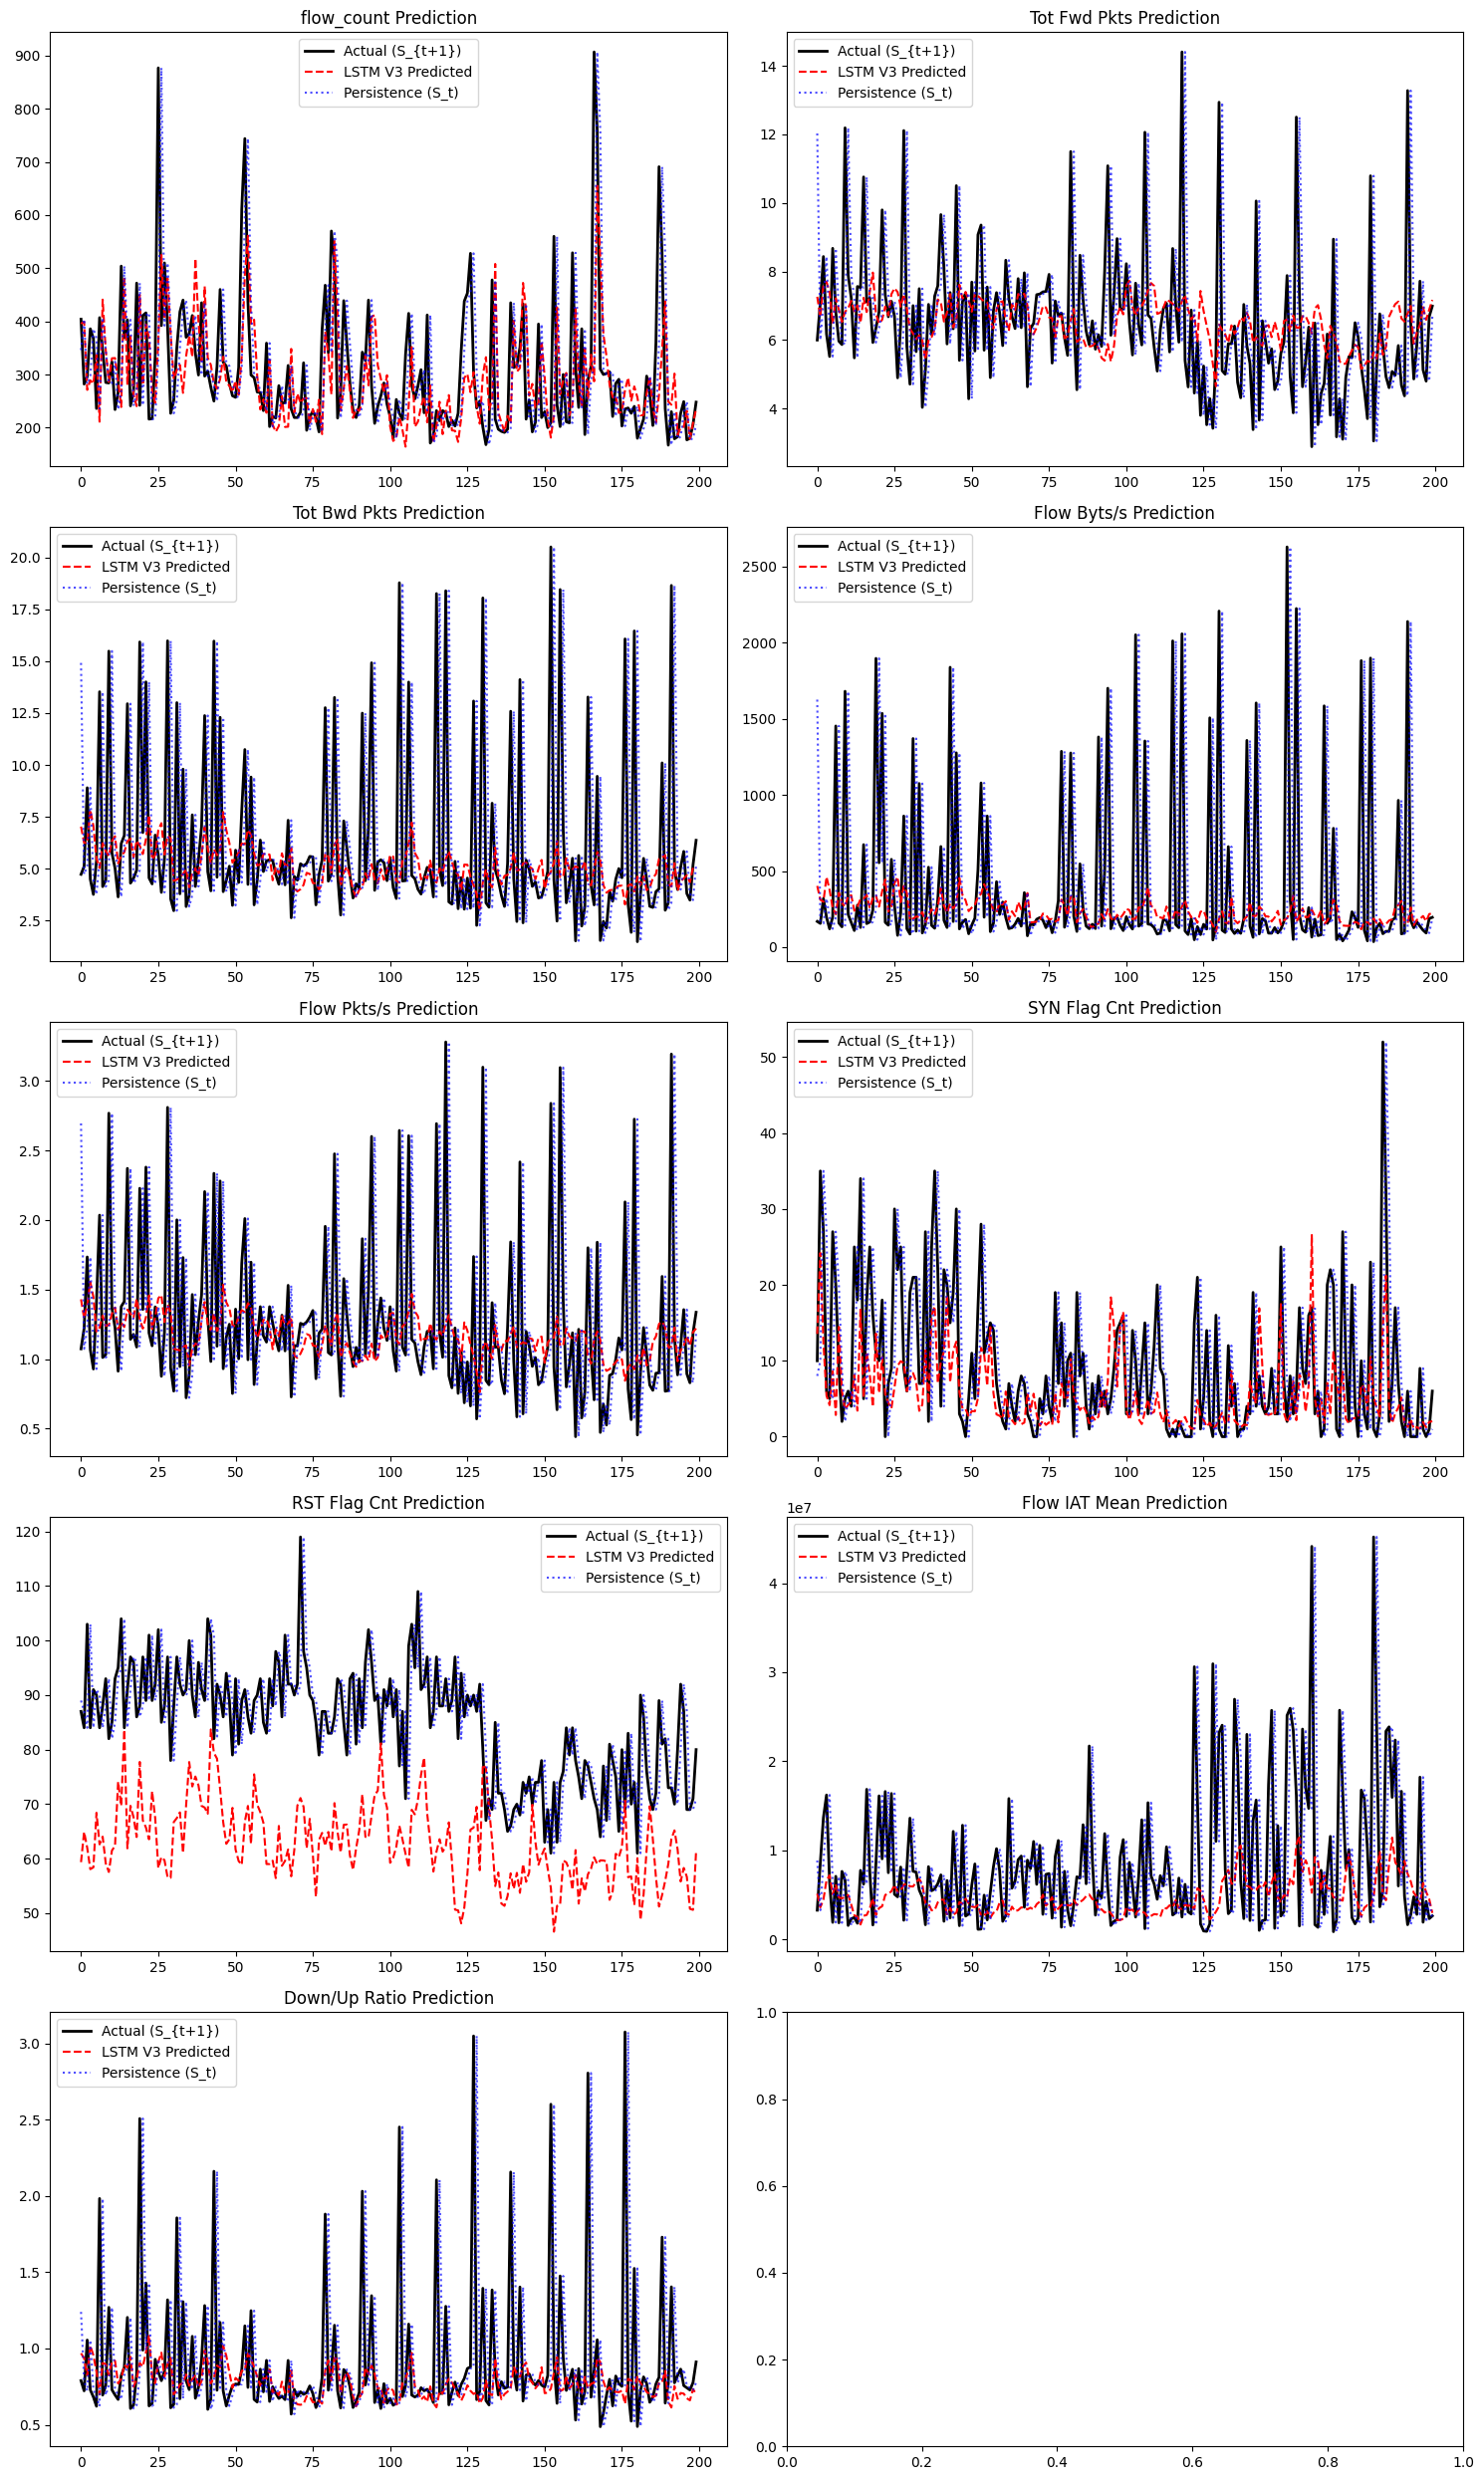

In [8]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(5, 2, figsize=(15, 25))
axes = axes.flatten()
plot_len = min(200, len(y_true_orig))

for idx, feat in enumerate(important_features):
    if feat in feature_names:
        f_idx = feature_names.index(feat)
        ax = axes[idx]
        ax.plot(y_true_orig[:plot_len, f_idx], label="Actual (S_{t+1})", color="black", linewidth=2)
        ax.plot(lstm_S_hat[:plot_len, f_idx], label="LSTM V3 Predicted", color="red", linestyle="--")
        ax.plot(pers_preds_orig[:plot_len, f_idx], label="Persistence (S_t)", color="blue", linestyle=":", alpha=0.7)
        ax.set_title(f"{feat} Prediction")
        ax.legend()

plt.tight_layout()
plt.show()



## [PHASE 3.3] K-STEP RECURSIVE FORECASTING (VALIDATION ONLY)

### Objective
Evaluate the temporal stability and error accumulation of the frozen V3 World Model over multiple forecast horizons ($K=1, 3, 5, 10, 20, 30$).

### Methodology
1. **Strict Causality**: For a given start state $S_t$, the model generates $\hat{S}_{t+1}$. This prediction is scaled exactly as the training data, appended to the history window, and fed recursively to predict $\hat{S}_{t+2}$, up to $\hat{S}_{t+K}$. Ground-truth states are NEVER used during generation.
2. **Primary Experiment**: Restricted to starting points where every consecutive transition up to $K$ is exactly 10 seconds.
3. **Secondary Diagnostic**: Includes all observed-state transitions, regardless of time gaps, measuring actual wall-clock elapsed time.
4. **Persistence Baseline**: $\hat{S}_{t+K} = S_t$ for all $K$.


In [9]:

K_HORIZONS = [1, 3, 5, 10, 20, 30]

# Extract Validation Timestamps and States
# idx_80 and idx_90 are defined in the earlier cells
val_indices = np.arange(idx_80, idx_90)
ts_val = S_t.index[val_indices]

# Prepare Batched Auto-regressive Generation
def batched_recursive_forecast(start_indices, K):
    # start_indices: array of indices i (relative to val_orig) representing state S_t
    # We need history [i - H + 1 : i + 1]
    
    N_starts = len(start_indices)
    batch_X_scaled = np.zeros((N_starts, H, 77), dtype=np.float32)
    
    for b_idx, i in enumerate(start_indices):
        batch_X_scaled[b_idx] = val_scaled_in[i - H + 1 : i + 1]
        
    batch_X = torch.tensor(batch_X_scaled, dtype=torch.float32).to(device)
    model.eval()
    
    with torch.no_grad():
        for k in range(1, K + 1):
            # Predict Primitives
            preds = model(batch_X).cpu().numpy()
            
            # Inverse Scale
            lstm_prim_log = preds * target_scales
            lstm_prim_orig = np.expm1(lstm_prim_log)
            
            # Deterministic Reconstruction
            S_hat = reconstruct_state(lstm_prim_orig, feature_names)
            
            # Forward Scale for next input
            S_hat_log = np.log1p(np.maximum(S_hat, 0))
            S_hat_scaled = input_scaler.transform(S_hat_log)
            
            # Update History Window
            if k < K:
                S_hat_scaled_t = torch.tensor(S_hat_scaled, dtype=torch.float32).unsqueeze(1).to(device)
                batch_X = torch.cat([batch_X[:, 1:, :], S_hat_scaled_t], dim=1)
                
    return S_hat, lstm_prim_orig

metrics_v3_recursive = {
    "Primary": {},
    "Secondary": {},
    "Error_Growth": []
}

for K in K_HORIZONS:
    # Find eligible starting points in validation set
    # i must be >= H - 1
    # i + K must be < len(val_orig)
    
    primary_starts = []
    secondary_starts = []
    wall_clocks = []
    
    for i in range(H - 1, len(val_orig) - K):
        # time delta from t to t+K
        t_start = ts_val[i]
        t_end = ts_val[i + K]
        elapsed = (t_end - t_start).total_seconds()
        
        # secondary
        secondary_starts.append(i)
        wall_clocks.append(elapsed)
        
        # primary: all K transitions are exactly 10s
        gaps = (ts_val[i:i+K+1][1:] - ts_val[i:i+K+1][:-1]).total_seconds()
        if np.all(gaps == 10.0):
            primary_starts.append(i)
            
    wall_clocks = np.array(wall_clocks)
    
    print(f"\n--- HORIZON K={K} ---")
    print(f"Secondary Starts: {len(secondary_starts)}")
    print(f"Wall-clock stats: Median={np.median(wall_clocks):.1f}s, Mean={np.mean(wall_clocks):.1f}s, Min={np.min(wall_clocks):.1f}s, Max={np.max(wall_clocks):.1f}s")
    print(f"Primary (Exactly 10s gaps) Starts: {len(primary_starts)}")
    
    if len(primary_starts) == 0:
        print(f"No eligible primary starts for K={K}. Skipping.")
        continue
        
    # Run Primary Batched Generation
    S_hat_K, prim_preds = batched_recursive_forecast(primary_starts, K)
    
    # Ground Truth & Persistence
    Y_true = np.zeros((len(primary_starts), 77))
    Y_pers = np.zeros((len(primary_starts), 77))
    for b_idx, i in enumerate(primary_starts):
        Y_true[b_idx] = val_orig[i + K]
        Y_pers[b_idx] = val_orig[i] # S_t (persistence)
        
    # Metrics
    res_lstm = calc_metrics(Y_true, S_hat_K)
    res_pers = calc_metrics(Y_true, Y_pers)
    
    # Physical Validity
    neg_prim = (prim_preds < 0).sum()
    neg_recon = (S_hat_K < 0).sum()
    
    derived_err = np.abs(S_hat_K[:, feature_names.index('Flow Pkts/s')] - ((S_hat_K[:, feature_names.index('Tot Fwd Pkts')] + S_hat_K[:, feature_names.index('Tot Bwd Pkts')]) / 10.0))
    violations = (derived_err > 1e-5).sum()
    
    print(f"LSTM RMSE: {res_lstm['RMSE']:.1f} | Persistence RMSE: {res_pers['RMSE']:.1f}")
    print(f"Physical Validity: Neg Primitives={neg_prim}, Neg Reconstructed={neg_recon}, Violations={violations}")
    
    # Feature Metrics
    f_metrics = []
    for f in important_features:
        if f not in feature_names: continue
        f_idx = feature_names.index(f)
        yt = Y_true[:, f_idx]
        lp = S_hat_K[:, f_idx]
        pp = Y_pers[:, f_idx]
        
        lstm_rmse = np.sqrt(mean_squared_error(yt, lp))
        pers_rmse = np.sqrt(mean_squared_error(yt, pp))
        
        f_metrics.append({
            "feature": f,
            "LSTM_RMSE": float(lstm_rmse),
            "Persistence_RMSE": float(pers_rmse)
        })
        
    metrics_v3_recursive["Primary"][f"K={K}"] = {
        "Eligible_Starts": len(primary_starts),
        "Nominal_Seconds": K * 10,
        "LSTM_Global": res_lstm,
        "Persistence_Global": res_pers,
        "Physical_Validity": {
            "Negative_Primitives": int(neg_prim),
            "Negative_Reconstructed": int(neg_recon),
            "Consistency_Violations": int(violations)
        },
        "Feature_Metrics": f_metrics
    }
    
    metrics_v3_recursive["Error_Growth"].append({
        "Horizon_K": K,
        "Nominal_Seconds": K * 10,
        "Eligible_Starts": len(primary_starts),
        "Median_Elapsed": float(np.median(wall_clocks)),
        "LSTM_RMSE": float(res_lstm['RMSE']),
        "Persistence_RMSE": float(res_pers['RMSE']),
        "LSTM_NRMSE": float(res_lstm['NRMSE']),
        "Persistence_NRMSE": float(res_pers['NRMSE'])
    })

# Save JSON
with open(RESULTS_DIR / "world_model" / "phase3_3_validation_metrics.json", "w") as f:
    json.dump(metrics_v3_recursive, f, indent=4)



--- HORIZON K=1 ---
Secondary Starts: 2851
Wall-clock stats: Median=10.0s, Mean=28.4s, Min=10.0s, Max=43210.0s
Primary (Exactly 10s gaps) Starts: 2841


LSTM RMSE: 7567915.9 | Persistence RMSE: 6545229.8
Physical Validity: Neg Primitives=0, Neg Reconstructed=0, Violations=0



--- HORIZON K=3 ---
Secondary Starts: 2849
Wall-clock stats: Median=30.0s, Mean=85.1s, Min=30.0s, Max=43230.0s
Primary (Exactly 10s gaps) Starts: 2821


LSTM RMSE: 7606356.0 | Persistence RMSE: 6750301.1
Physical Validity: Neg Primitives=0, Neg Reconstructed=0, Violations=0



--- HORIZON K=5 ---
Secondary Starts: 2847
Wall-clock stats: Median=50.0s, Mean=141.9s, Min=50.0s, Max=43250.0s
Primary (Exactly 10s gaps) Starts: 2804


...

LSTM RMSE: 8066238.1 | Persistence RMSE: 6860136.1
Physical Validity: Neg Primitives=0, Neg Reconstructed=0, Violations=0



--- HORIZON K=20 ---
Secondary Starts: 2832
Wall-clock stats: Median=200.0s, Mean=569.6s, Min=200.0s, Max=43400.0s
Primary (Exactly 10s gaps) Starts: 2730


LSTM RMSE: 8216971.2 | Persistence RMSE: 6992603.5
Physical Validity: Neg Primitives=0, Neg Reconstructed=0, Violations=0



--- HORIZON K=30 ---
Secondary Starts: 2822
Wall-clock stats: Median=300.0s, Mean=856.3s, Min=300.0s, Max=43500.0s
Primary (Exactly 10s gaps) Starts: 2700


LSTM RMSE: 8264799.8 | Persistence RMSE: 7068413.7
Physical Validity: Neg Primitives=0, Neg Reconstructed=0, Violations=0



### Error Accumulation Over Horizons


,Horizon_K,Nominal_Seconds,Eligible_Starts,Median_Elapsed,LSTM_RMSE,Persistence_RMSE,LSTM_NRMSE,Persistence_NRMSE
0,1,10,2841,10.0,7.567916e+06,6.545230e+06,0.063066,0.054544
1,3,30,2821,30.0,7.606356e+06,6.750301e+06,0.063386,0.056253
2,5,50,2804,50.0,7.895328e+06,6.834560e+06,0.065794,0.056955
3,10,100,2773,100.0,8.066238e+06,6.860136e+06,0.067219,0.057168
4,20,200,2730,200.0,8.216971e+06,6.992603e+06,0.068475,0.058272
5,30,300,2700,300.0,8.264800e+06,7.068414e+06,0.068873,0.058903


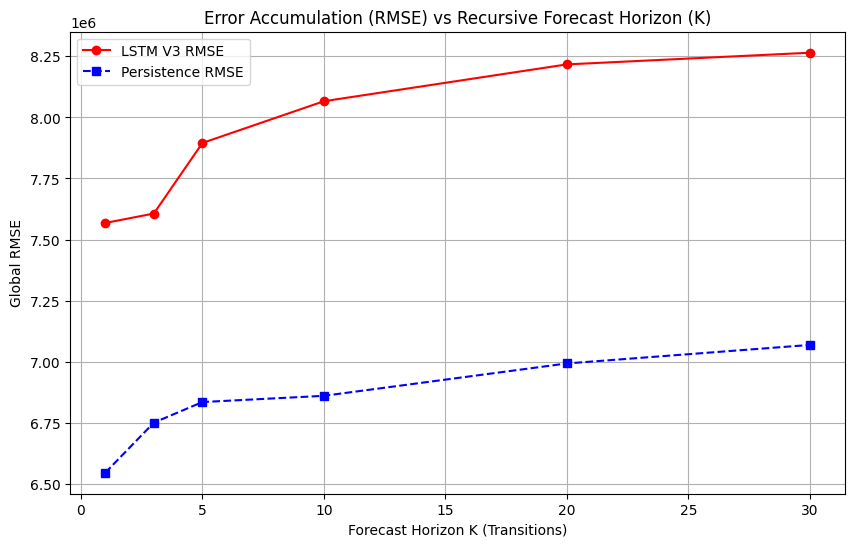

In [10]:

import matplotlib.pyplot as plt

growth_df = pd.DataFrame(metrics_v3_recursive["Error_Growth"])
display(growth_df)

plt.figure(figsize=(10, 6))
plt.plot(growth_df["Horizon_K"], growth_df["LSTM_RMSE"], marker='o', color='red', label='LSTM V3 RMSE')
plt.plot(growth_df["Horizon_K"], growth_df["Persistence_RMSE"], marker='s', color='blue', linestyle='--', label='Persistence RMSE')
plt.title("Error Accumulation (RMSE) vs Recursive Forecast Horizon (K)")
plt.xlabel("Forecast Horizon K (Transitions)")
plt.ylabel("Global RMSE")
plt.legend()
plt.grid(True)
plt.show()
